# Energy Simulation with PyBaMM

This notebook demonstrates how to perform energy/capacity simulation using PyBaMM with BYD Blade Prismatic 135Ah cell parameters.

## Overview
- **Cell**: BYD Blade Prismatic 135Ah LFP
- **Chemistry**: LFP (Lithium Iron Phosphate)
- **Form Factor**: Prismatic
- **Nominal Voltage**: 3.3V
- **Capacity**: 135Ah
- **Simulations**: Full discharge energy characterization at multiple C-rates

In [1]:
# Import required libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model_library import run_spmet_manifest

## 1. Load Cell Parameters

Load the cell design from the manifest file.

In [2]:
# Load cell manifest
manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
material_path = Path("../materials")
# manifest_path = Path("../cells/BYD_Blade_Prismatic_135Ah_manifest.json")

with open(manifest_path, "r") as f:
    cell_design_manifest = json.load(f)
    # Load material data for separator and electrolyte
    for component in ["separator", "electrolyte"]:
        print(f"Loading material data for {component}")
        material_name = cell_design_manifest["cell_design"][component]["material"][
            "type"
        ]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

    # Load material data for electrodes
    for component in ["negative_electrode", "positive_electrode"]:
        print(f"Loading material data for {component}")
        material_name = cell_design_manifest["cell_design"][component]["coating"][
            "formulation"
        ]["primary_active_material"]["name"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data
# ============================================================================
# FITTED PARAMETERS FROM EXPERIMENTAL DATA
# ============================================================================
cell_design_manifest["cell_design"]["negative_electrode"]["coating"][
    "bruggeman_coefficient"
] = {"value": 1.5, "unit": "1"}
cell_design_manifest["cell_design"]["positive_electrode"]["coating"][
    "bruggeman_coefficient"
] = {"value": 1.5, "unit": "1"}
# ============================================================================
# ENERGY TEST CONFIGURATION
# ============================================================================
c_rates = [0.2, 0.5, 1.0, 2.0]
upper_voltage_cutoff = cell_design_manifest["cell_design"]["upper_voltage_cutoff"][
    "value"
]
lower_voltage_cutoff = cell_design_manifest["cell_design"]["lower_voltage_cutoff"][
    "value"
]
#
# Build experiment strings for each C-rate
experiments = []
labels = []
for c_rate in c_rates:
    max_time_s = int(3600 / c_rate * 1.2)  # 20% margin
    experiments.append(f"Discharge at {c_rate}C for {max_time_s} seconds or until {lower_voltage_cutoff} V")
    labels.append(f"{c_rate}C")


# Energy test configuration dictionary
energy_config = {
    "ambient_temperature": 298.15,  # 25°C
    "initial_temperature": 298.15,  # 25°C
    "initial_soc": 0.5,  # 50% SOC
    "c_rate": 1.0,  # 1C discharge
    "direction": "discharge",
    "duration_s": 30,
    "upper_voltage_cutoff": upper_voltage_cutoff,
    "lower_voltage_cutoff": lower_voltage_cutoff,
    "contact_resistance": 0.000001,
    "total_heat_transfer_coefficient": 10,
    "cooling_surface_area": 0.001,
    "experiments": experiments,
    "experiment_labels": labels,
}

Loading material data for separator
Loading material data for electrolyte
Loading material data for negative_electrode
Loading material data for positive_electrode


## 2. Run Energy Simulation

Run the SPMeT model with energy experiment configuration at multiple C-rates.

In [3]:
results = run_spmet_manifest(cell_design_manifest=cell_design_manifest, simulation_config=energy_config)


Building model parameters from manifest...
  Positive electrode: sto_0=0.9990, sto_100=0.0010
  Negative electrode: sto_0=0.0539, sto_100=0.9959
  OCV at 0% cell SOC: 2.514 - 1.001 = 1.513 V
  OCV at 100% cell SOC: 3.838 - 0.009 = 3.829 V
  Parameters loaded

CAPACITY CALIBRATION
Target capacity: 161.10 Ah
Charge current: 53.70 A (C/3), Discharge current: 16.11 A (C/10)
Upper voltage: 3.65 V, Lower voltage: 2.5 V
Nominal capacity in params: 161.10 Ah
Pos sto limits: min=0.0010, max=0.9990
Neg sto limits: min=0.0539, max=0.9959
PyBaMM calculated cell capacity: 161.10 Ah
Experiment steps:
  1. Rest, Charge at 0.1C until 3.65 V, Hold at 3.65 V for 2 hours or until C/50
  2. Rest
  3. Discharge at 0.1C for 15 hours or until 2.5 V
  4. Rest
Convergence tolerance: 0.010%
--------------------------------------------------------------------------------
Iteration  1: Capacity =  27.60 Ah, Error = 82.866%
Iteration  2: Capacity = 241.65 Ah, Error = 50.000%
Iteration  3: Capacity = 241.65 Ah, Er

## 3. Post-Processing: Calculate Energy Metrics

Extract energy, capacity, and other metrics from the raw time series data.

In [4]:
# Post-processing: Calculate energy metrics from time series
successful_results = [r for r in results if r['success']]

energy_metrics = []
for r in successful_results:
    time_s = r['time_s']
    voltage_V = r['voltage_V']
    energy_Wh = r['energy_Wh']
    capacity_Ah = r['capacity_Ah']
    temperature_K = r['temperature_K']
    
    # Calculate metrics
    discharge_capacity_Ah = float(capacity_Ah[-1] - capacity_Ah[0])
    discharge_energy_Wh = float(energy_Wh[-1] - energy_Wh[0])
    average_voltage_V = discharge_energy_Wh / discharge_capacity_Ah if discharge_capacity_Ah > 0 else 0
    max_temperature_C = float(temperature_K.max() - 273.15)
    duration_min = float(time_s[-1] - time_s[0]) / 60
    
    # Extract C-rate from label
    c_rate = float(r['experiment_label'].replace('C', ''))
    
    energy_metrics.append({
        'c_rate': c_rate,
        'discharge_capacity_Ah': discharge_capacity_Ah,
        'discharge_energy_Wh': discharge_energy_Wh,
        'average_voltage_V': average_voltage_V,
        'max_temperature_C': max_temperature_C,
        'duration_min': duration_min,
        'time_s': time_s,
        'voltage_V': voltage_V,
        'capacity_Ah': capacity_Ah,
        'temperature_K': temperature_K,
    })

# Display summary
if energy_metrics:
    summary_data = [{
        'C-rate': f"{m['c_rate']}C",
        'Capacity [Ah]': f"{m['discharge_capacity_Ah']:.2f}",
        'Energy [Wh]': f"{m['discharge_energy_Wh']:.2f}",
        'Avg Voltage [V]': f"{m['average_voltage_V']:.3f}",
        'Duration [min]': f"{m['duration_min']:.1f}",
        'Max Temp [C]': f"{m['max_temperature_C']:.1f}",
    } for m in energy_metrics]
    
    summary_df = pd.DataFrame(summary_data)
    print("\nEnergy Simulation Results:")
    print(summary_df.to_string(index=False))


Energy Simulation Results:
C-rate Capacity [Ah] Energy [Wh] Avg Voltage [V] Duration [min] Max Temp [C]
  0.2C         66.33      211.51           3.189          123.5         25.7
  0.5C         54.10      172.49           3.189           40.3         26.3
  1.0C         50.51      160.62           3.180           18.8         27.4
  2.0C         48.66      153.54           3.155            9.1         29.5


## 4. Visualize Results

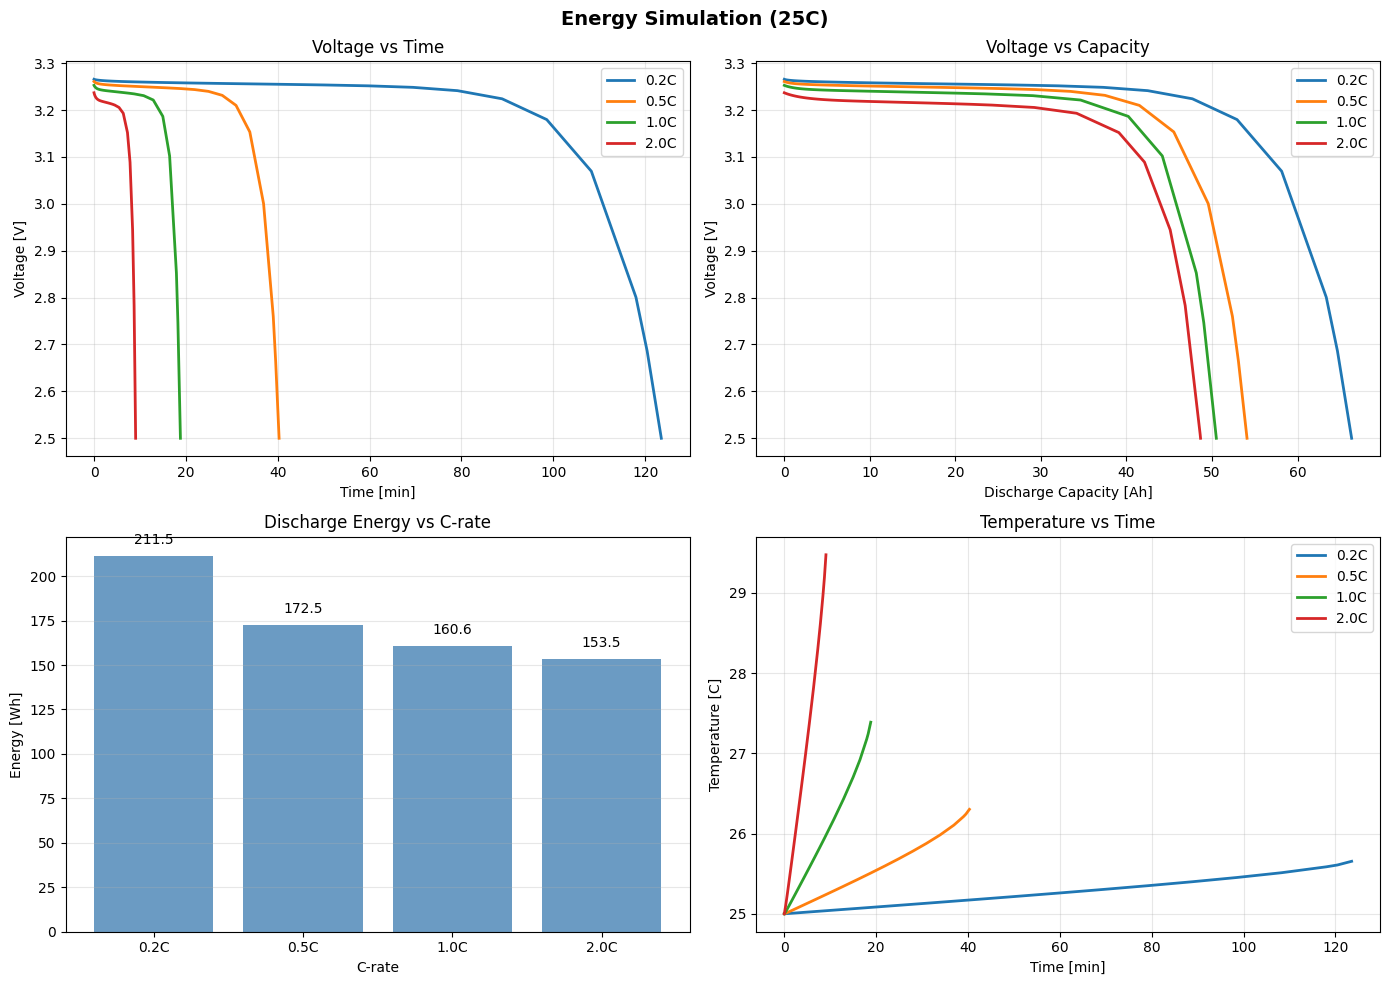

In [5]:
if len(energy_metrics) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Voltage vs Time for all C-rates
    ax1 = axes[0, 0]
    for m in energy_metrics:
        time_min = (m['time_s'] - m['time_s'][0]) / 60
        ax1.plot(time_min, m['voltage_V'], linewidth=2, label=f"{m['c_rate']}C")
    ax1.set_xlabel('Time [min]')
    ax1.set_ylabel('Voltage [V]')
    ax1.set_title('Voltage vs Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Voltage vs Capacity for all C-rates
    ax2 = axes[0, 1]
    for m in energy_metrics:
        capacity = m['capacity_Ah'] - m['capacity_Ah'][0]
        ax2.plot(capacity, m['voltage_V'], linewidth=2, label=f"{m['c_rate']}C")
    ax2.set_xlabel('Discharge Capacity [Ah]')
    ax2.set_ylabel('Voltage [V]')
    ax2.set_title('Voltage vs Capacity')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Energy vs C-rate (bar chart)
    ax3 = axes[1, 0]
    c_rates_plot = [m['c_rate'] for m in energy_metrics]
    energies = [m['discharge_energy_Wh'] for m in energy_metrics]
    bars = ax3.bar([f"{c}C" for c in c_rates_plot], energies, color='steelblue', alpha=0.8)
    ax3.set_xlabel('C-rate')
    ax3.set_ylabel('Energy [Wh]')
    ax3.set_title('Discharge Energy vs C-rate')
    ax3.grid(True, alpha=0.3, axis='y')
    for bar, energy in zip(bars, energies):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 f'{energy:.1f}', ha='center', va='bottom', fontsize=10)

    # Plot 4: Temperature vs Time for all C-rates
    ax4 = axes[1, 1]
    for m in energy_metrics:
        time_min = (m['time_s'] - m['time_s'][0]) / 60
        temp_C = m['temperature_K'] - 273.15
        ax4.plot(time_min, temp_C, linewidth=2, label=f"{m['c_rate']}C")
    ax4.set_xlabel('Time [min]')
    ax4.set_ylabel('Temperature [C]')
    ax4.set_title('Temperature vs Time')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle(f'Energy Simulation ({energy_config["ambient_temperature"]-273.15:.0f}C)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No successful simulations to plot.")